# Energy Thief — Level 1: Tabular Q-Learning

**Project VFA-4.** The agent is a thief on a small **power-grid network**: a
**plant** generates energy that flows through a **substation** out to several
**consumers**. Generation never matches demand exactly, so some edges carry more
than their consumer needs — that excess is **slack** (the grid's inefficiency).

The thief steals by **redirecting flow** off an edge, building an **unbanked
surplus** of diverted energy that it benefits from every step it keeps it. A
monitoring system can raise an **alarm** that wipes the surplus. Level 1 is the
smallest of the three complexity levels, sized so a **tabular** method can solve it.

## The MDP

Finite MDP $\mathcal{M} = \langle \mathcal{S}, \mathcal{A}, P, R, \gamma, \rho_0 \rangle$.
The grid is a plant → substation → $n$ consumers. Each consumer edge $c$ carries a
**flow** $f_c$ and divertible **slack** $s_c$; a **demand phase** $\phi$ fixes the
flows, slacks, and monitoring sensitivity $\varsigma(\phi)$ (higher phase = tighter
grid, less slack, closer watch).

**State space.** Slack is a deterministic function of the phase, so the state is the
phase and the unbanked surplus:
$$s = (\phi, U), \qquad \phi \in \{0,\dots,n_\phi-1\}, \quad U \in \{0,\dots,U_{\max}\},$$
$$\operatorname{id}(s) = \phi\,(U_{\max}+1) + U, \qquad |\mathcal{S}| = n_\phi(U_{\max}+1) = 4\cdot 9 = 36.$$
No terminal state; $\rho_0$ deterministic at $(\phi,U)=(0,0)$.

**Actions.** For each consumer edge, **skim** (divert only the slack) or **overdraw**
(take the slack *plus* $\Delta$ from delivered demand, starving the consumer), plus
**lie-low** (operate nothing this step): $|\mathcal{A}| = 2n + 1 = 7$.

**Transitions.** The phase drifts by an exogenous random walk
$\phi' = \operatorname{clip}(\phi + \xi)$, $\xi\in\{-1,0,+1\}$ w.p. $(0.25,0.5,0.25)$.
A tap diverts $\text{take}$ energy (bounded by the flow and by the surplus cap),
causing a delivered-demand **shortfall** $h = \max(0, \text{take}-s_c)$ ($h=0$ for a
skim). The alarm fires with $p = \min(1, \varsigma(\phi)(\beta_0 + \beta_h h))$; on an
alarm $U\!\to\!0$, otherwise $U' = U + \text{take}$. Lie-low changes nothing.

**Reward.** The thief benefits from the diverted energy it holds:
$$R = U' \quad(\text{the surplus held after the step}).$$
An alarm sets $U'=0$, so the step after a bust earns nothing until the surplus is
rebuilt. This makes the goal **accumulate a large surplus and avoid losing it** —
exactly the brief's "accumulate surplus while avoiding detection."

**Objective.** Maximize the expected $\gamma$-discounted return ($\gamma=0.99$)
$G_t = \sum_{k\ge0}\gamma^k R_{t+k+1}$, i.e. learn $q_\star(s,a)$ satisfying the
Bellman optimality equation and act greedily. The key decision is **how aggressively
to operate**: overdraw is worth the alarm risk only when there is little surplus to
lose, so the thief skims safely once its stash is large and lies low when the grid
is too tight to skim.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

from energy_thief.envs import GridThiefEnv, ACTION_NAMES
from energy_thief.agents import QLearningAgent

rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 110

In [2]:
env = GridThiefEnv(seed=1)
print(f"states: {env.n_states}   actions: {env.n_actions}")
print(f"consumers: {env.consumers}")
print(f"action names: {ACTION_NAMES}")
print("divertible slack per (phase, consumer):")
print(env.slack)
print(f"monitoring sensitivity per phase: {np.round(env.sens, 3)}")
print(env.render())

states: 36   actions: 7
consumers: ('C1', 'C2', 'C3')
action names: ['skim-C1', 'overdraw-C1', 'skim-C2', 'overdraw-C2', 'skim-C3', 'overdraw-C3', 'lie-low']
divertible slack per (phase, consumer):
[[2 1 0]
 [1 0 1]
 [0 1 0]
 [0 0 0]]
monitoring sensitivity per phase: [0.1 0.2 0.3 0.4]
t=0   phase=0 (sens=0.10)  surplus=0/8  flows[C1:3(+2) C2:3(+1) C3:3(+0)]


## The environment at a glance

**Left:** the network — a plant feeds the consumers through a substation. **Middle:**
the divertible **slack** (waste) on each consumer edge in each demand phase — the map
of *where it is safe to redirect flow*, and it shifts phase to phase. **Right:** the
alarm probability of a **skim** (only slack, no shortfall) vs an **overdraw** (dip into
delivered demand) — overdrawing is several times riskier, and both climb as the grid
tightens.

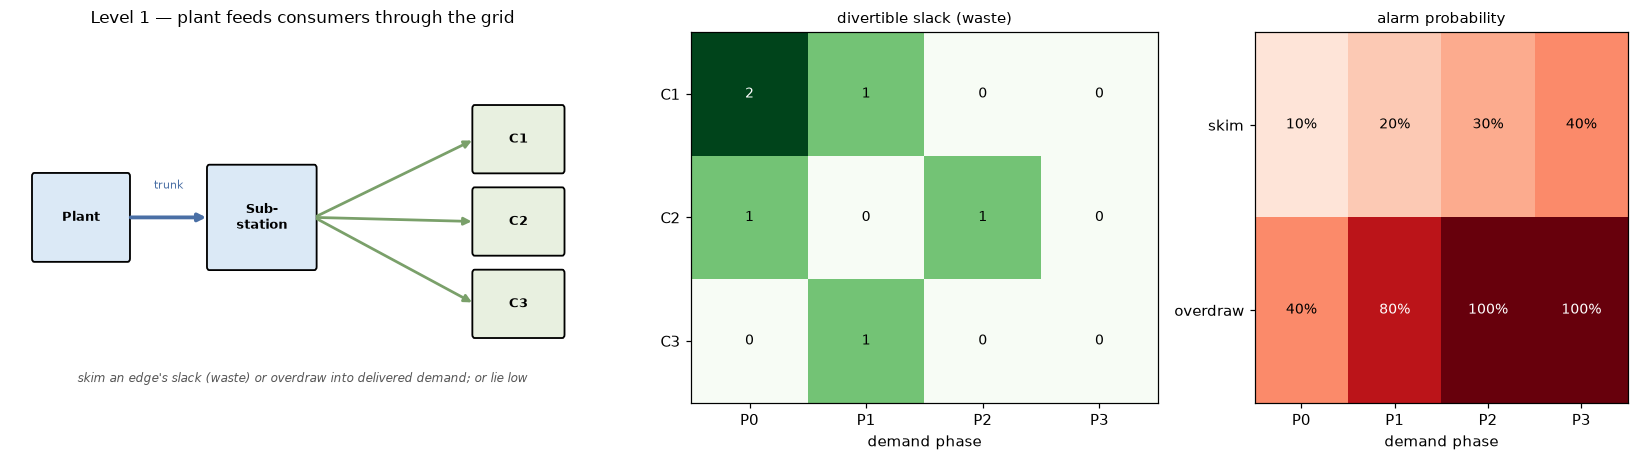

In [3]:
fig, (axS, axK, axR) = plt.subplots(1, 3, figsize=(15, 4.3),
                                    gridspec_kw={"width_ratios": [1.25, 1, 0.8]})
n = env.n_consumers

# Panel 1: network schematic
axS.set_xlim(0, 10); axS.set_ylim(0, n + 1.5); axS.axis("off")
def box(x, y, w, h, label, fc):
    axS.add_patch(FancyBboxPatch((x - w/2, y - h/2), w, h, boxstyle="round,pad=0.04",
                  fc=fc, ec="black", lw=1.2))
    axS.text(x, y, label, ha="center", va="center", fontsize=8.5, weight="bold")
ymid = (n + 1.5) / 2
box(1.2, ymid, 1.6, 1.0, "Plant", "#dbe9f6")
box(4.3, ymid, 1.8, 1.2, "Sub-\nstation", "#dbe9f6")
axS.annotate("", xy=(3.4, ymid), xytext=(2.0, ymid),
             arrowprops=dict(arrowstyle="-|>", lw=2.5, color="#4a6fa5"))
axS.text(2.7, ymid + 0.35, "trunk", ha="center", fontsize=7.5, color="#4a6fa5")
for i, c in enumerate(env.consumers):
    y = n - i + 0.2
    box(8.7, y, 1.5, 0.75, c, "#e8f0e0")
    axS.annotate("", xy=(7.95, y), xytext=(5.2, ymid),
                 arrowprops=dict(arrowstyle="-|>", lw=1.8, color="#7aa06a"))
axS.set_title("Level 1 — plant feeds consumers through the grid", fontsize=11)
axS.text(5.0, 0.25, "skim an edge's slack (waste) or overdraw into delivered demand; or lie low",
         ha="center", fontsize=8, style="italic", color="#555")

# Panel 2: divertible slack per (consumer x phase)
axK.imshow(env.slack.T, cmap="Greens", aspect="auto", vmin=0, vmax=max(1, env.slack.max()))
for i in range(n):
    for ph in range(env.n_phase):
        axK.text(ph, i, str(env.slack[ph, i]), ha="center", va="center", fontsize=9,
                 color="white" if env.slack[ph, i] > env.slack.max()*0.6 else "black")
axK.set_xticks(range(env.n_phase)); axK.set_xticklabels([f"P{p}" for p in range(env.n_phase)])
axK.set_yticks(range(n)); axK.set_yticklabels(env.consumers)
axK.set_xlabel("demand phase"); axK.set_title("divertible slack (waste)", fontsize=10)

# Panel 3: skim vs overdraw alarm probability per phase
risk = np.array([
    [min(1.0, env.sens[ph] * env.base_divert) for ph in range(env.n_phase)],
    [min(1.0, env.sens[ph] * (env.base_divert + env.shortfall_weight * env.overdraw_extra))
     for ph in range(env.n_phase)],
])
axR.imshow(risk, cmap="Reds", aspect="auto", vmin=0, vmax=1)
for r in range(2):
    for ph in range(env.n_phase):
        axR.text(ph, r, f"{risk[r,ph]*100:.0f}%", ha="center", va="center", fontsize=9,
                 color="white" if risk[r, ph] > 0.5 else "black")
axR.set_xticks(range(env.n_phase)); axR.set_xticklabels([f"P{p}" for p in range(env.n_phase)])
axR.set_yticks([0, 1]); axR.set_yticklabels(["skim", "overdraw"])
axR.set_xlabel("demand phase"); axR.set_title("alarm probability", fontsize=10)
fig.tight_layout(); plt.show()

## Tabular Q-learning

Off-policy TD control: learn $q_\star$ from experience, without knowing $P$. Keep a
table $Q(s,a)$ and, after each transition $(S_t, A_t, R_{t+1}, S_{t+1})$, step toward
the one-sample Bellman target:
$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \big[\, R_{t+1} + \gamma \max_{a} Q(S_{t+1}, a) - Q(S_t, A_t) \,\big].$$

## Training loop

One episode = one shift ($T$ steps). We act $\varepsilon$-greedily, anneal
$\varepsilon$ over episodes, and repeat over 5 seeds for a variance band.

In [4]:
def evaluate(env, agent, n_episodes=1000):
    rets = np.empty(n_episodes)
    for ep in range(n_episodes):
        s, _ = env.reset()
        done, g = False, 0.0
        while not done:
            a = agent.select_action(s, greedy=True)
            s, r, term, trunc, _ = env.step(a)
            g, done = g + r, term or trunc
        rets[ep] = g
    return rets.mean(), rets.std()


def train(env, n_episodes, seed, eval_env=None, eval_every=250, eval_episodes=50, **kw):
    agent = QLearningAgent(env.n_states, env.action_space.n, seed=seed, **kw)
    returns = np.empty(n_episodes)
    epsilons = np.empty(n_episodes)
    eval_x, eval_y = [], []
    for ep in range(n_episodes):
        s, _ = env.reset()
        done, g = False, 0.0
        while not done:
            a = agent.select_action(s)
            s2, r, term, trunc, _ = env.step(a)
            agent.update(s, a, r, s2, term)
            s, g, done = s2, g + r, term or trunc
        returns[ep] = g
        epsilons[ep] = agent.epsilon
        agent.end_episode()
        if eval_env is not None and (ep + 1) % eval_every == 0:
            m, _ = evaluate(eval_env, agent, eval_episodes)
            eval_x.append(ep + 1); eval_y.append(m)
    return agent, returns, np.array(eval_x), np.array(eval_y), epsilons

In [5]:
N_EPISODES = 8000
SEEDS = range(5)
HP = dict(alpha=0.1, gamma=0.99, epsilon_decay=0.999)

curves, eval_curves, agents = [], [], []
eval_x, epsilons = None, None
for seed in SEEDS:
    agent, returns, ex, ey, eps = train(
        GridThiefEnv(seed=1), N_EPISODES, seed=seed, eval_env=GridThiefEnv(seed=1), **HP)
    curves.append(returns); eval_curves.append(ey); agents.append(agent)
    eval_x = ex
    epsilons = eps if epsilons is None else epsilons
curves = np.array(curves); eval_curves = np.array(eval_curves)
print("training done:", curves.shape)

training done: (5, 8000)


## Learning curve

Return per episode (= total surplus held over the shift), averaged over seeds
(band = ±1 std, 100-episode moving average).

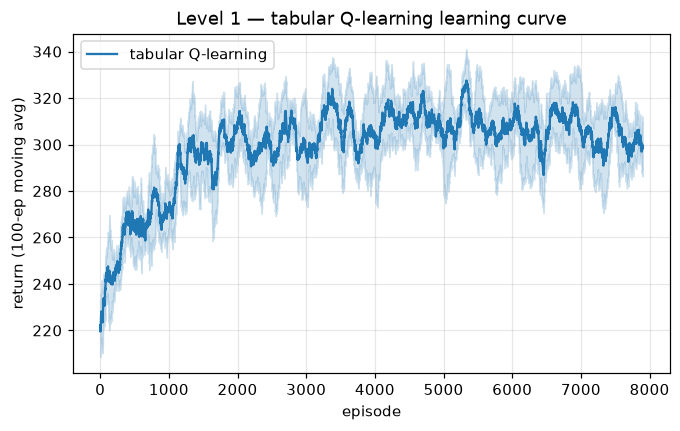

In [6]:
def moving_average(x, w=100):
    return np.convolve(x, np.ones(w) / w, mode="valid")

smoothed = np.array([moving_average(c) for c in curves])
mean, std = smoothed.mean(0), smoothed.std(0)
x = np.arange(smoothed.shape[1])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, mean, color="C0", label="tabular Q-learning")
ax.fill_between(x, mean - std, mean + std, color="C0", alpha=0.2)
ax.set_xlabel("episode"); ax.set_ylabel("return (100-ep moving avg)")
ax.set_title("Level 1 — tabular Q-learning learning curve")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

## Greedy evaluation return

The greedy policy (no exploration), evaluated every 250 episodes — the smooth curve
that matters. We also compare against a **random** policy to show that timing the
thefts is real skill.

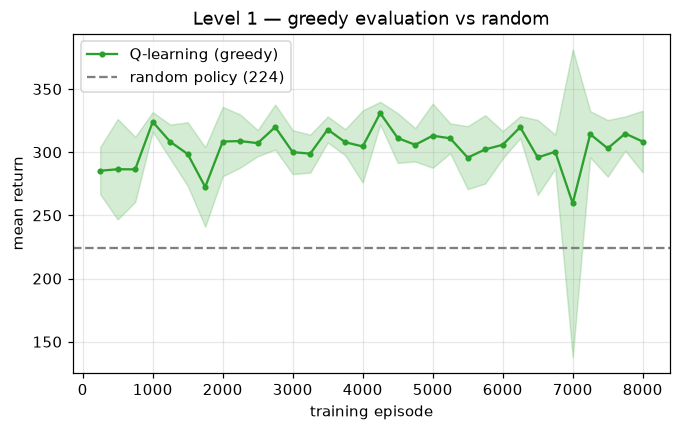

final greedy return: +308 ± 24   (random +224)


In [7]:
ev_mean, ev_std = eval_curves.mean(0), eval_curves.std(0)

def random_return(env, n=1000):
    r = np.empty(n)
    for i in range(n):
        s, _ = env.reset(); done, g = False, 0.0
        while not done:
            a = int(rng.integers(env.n_actions))
            s, rr, term, trunc, _ = env.step(a); g += rr; done = term or trunc
        r[i] = g
    return r.mean(), r.std()
rand_m, rand_s = random_return(GridThiefEnv(seed=1))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(eval_x, ev_mean, color="C2", marker="o", ms=3, label="Q-learning (greedy)")
ax.fill_between(eval_x, ev_mean - ev_std, ev_mean + ev_std, color="C2", alpha=0.2)
ax.axhline(rand_m, ls="--", color="C7", label=f"random policy ({rand_m:.0f})")
ax.set_xlabel("training episode"); ax.set_ylabel("mean return")
ax.set_title("Level 1 — greedy evaluation vs random")
ax.legend(); ax.grid(alpha=0.3)
plt.show()
print(f"final greedy return: {ev_mean[-1]:+.0f} ± {ev_std[-1]:.0f}   (random {rand_m:+.0f})")

## Exploration schedule

$\varepsilon$ annealed geometrically from 1 to its floor $\varepsilon_{\min}$.

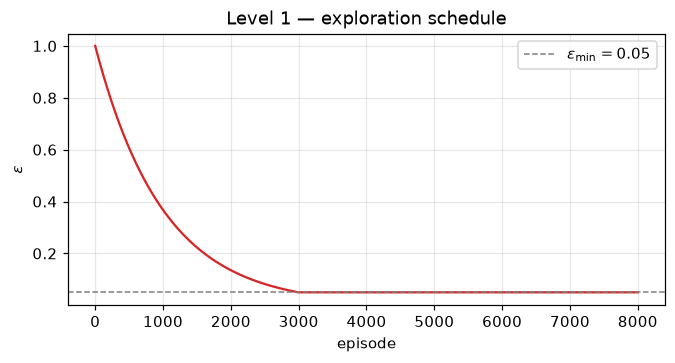

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(np.arange(len(epsilons)), epsilons, color="C3")
ax.axhline(agents[0].epsilon_min, ls="--", color="grey", lw=1,
           label=fr"$\varepsilon_{{\min}} = {agents[0].epsilon_min}$")
ax.set_xlabel("episode"); ax.set_ylabel(r"$\varepsilon$")
ax.set_title("Level 1 — exploration schedule")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

## The learned policy

The state is just $(\text{phase}, \text{surplus})$, so the greedy policy fits in one
table. Cells show the chosen action (**sk**$c$ = skim consumer $c$, **ov**$c$ =
overdraw, **low** = lie low). The risk-sensitive pattern: **overdraw when the surplus
is small** (little to lose from an alarm) and the grid is loose, but **skim safely or
lie low once the surplus is large** — a bust would wipe a big stash.

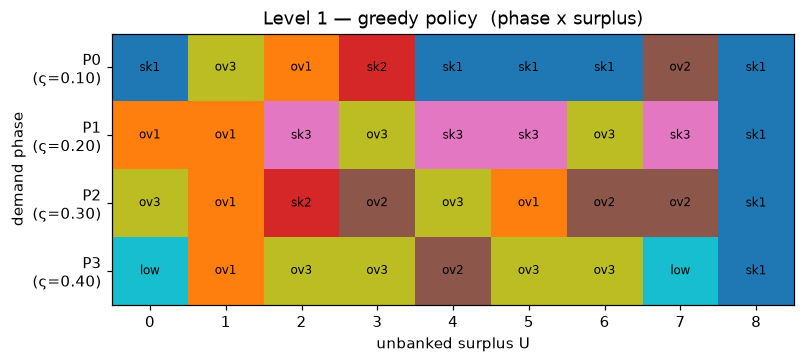

In [9]:
def short(a):
    if a == env.LIE_LOW:
        return "low"
    c, ov = divmod(a, 2)
    return f"{'ov' if ov else 'sk'}{c+1}"

policy = agents[0].greedy_policy().reshape(env.n_phase, env.surplus_max + 1)
cmap = plt.get_cmap("tab10", env.n_actions)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.imshow(policy, cmap=cmap, vmin=0, vmax=env.n_actions - 1, aspect="auto")
for P in range(env.n_phase):
    for U in range(env.surplus_max + 1):
        ax.text(U, P, short(policy[P, U]), ha="center", va="center", fontsize=8)
ax.set_xticks(range(env.surplus_max + 1)); ax.set_yticks(range(env.n_phase))
ax.set_yticklabels([f"P{P}\n(ς={env.sens[P]:.2f})" for P in range(env.n_phase)])
ax.set_xlabel("unbanked surplus U"); ax.set_ylabel("demand phase")
ax.set_title("Level 1 — greedy policy  (phase x surplus)")
plt.show()

## A single shift, step by step

One greedy episode. Top: the demand phase drifting. Middle: the surplus — the thing
being rewarded — with alarms ($\times$) that knock it to zero. Bottom: **which
consumer edge the thief redirects flow from** each step (● skim, ▲ overdraw; gaps are
lie-low). Watch it build a stash, protect it, and occasionally get busted.

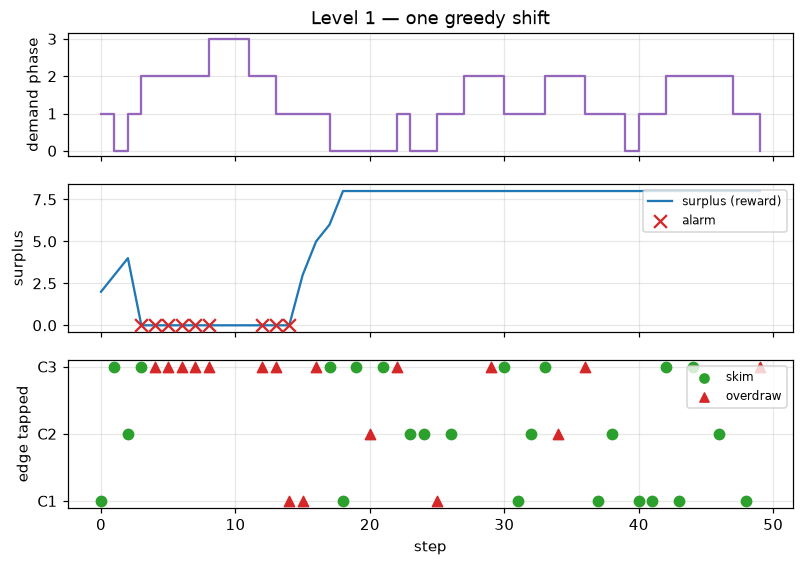

In [10]:
def greedy_trace(env, agent):
    s, _ = env.reset()
    phases, surplus, alarms, taps = [], [], [], []
    done, t = False, 0
    while not done:
        a = agent.select_action(s, greedy=True)
        s, r, term, trunc, info = env.step(a)
        phases.append(info["phase"]); surplus.append(info["surplus"])
        if info["alarm"]: alarms.append(t)
        if info["tapped"] >= 0: taps.append((t, info["tapped"], a % 2 == 1))
        done, t = term or trunc, t + 1
    return np.array(phases), np.array(surplus), alarms, taps

phases, surplus, alarms, taps = greedy_trace(GridThiefEnv(seed=7), agents[0])
steps = np.arange(len(phases))

fig, (a1, a2, a3) = plt.subplots(3, 1, figsize=(8.5, 5.6), sharex=True,
                                 gridspec_kw={"height_ratios": [1, 1.2, 1.2]})
a1.step(steps, phases, where="post", color="C4"); a1.set_ylabel("demand phase")
a1.set_yticks(range(env.n_phase)); a1.grid(alpha=0.3)
a1.set_title("Level 1 — one greedy shift")

a2.plot(steps, surplus, color="C0", label="surplus (reward)")
if alarms:
    a2.scatter(alarms, np.zeros(len(alarms)), marker="x", color="C3", s=70, zorder=3, label="alarm")
a2.set_ylabel("surplus"); a2.grid(alpha=0.3); a2.legend(loc="upper right", fontsize=8)

for t, c, ov in taps:
    a3.scatter(t, c, marker="^" if ov else "o", color="C3" if ov else "C2", s=45, zorder=3)
a3.set_yticks(range(env.n_consumers)); a3.set_yticklabels(env.consumers)
a3.set_ylabel("edge tapped"); a3.set_xlabel("step"); a3.grid(alpha=0.3)
a3.scatter([], [], marker="o", color="C2", label="skim"); a3.scatter([], [], marker="^", color="C3", label="overdraw")
a3.legend(loc="upper right", fontsize=8)
plt.show()

## Takeaways

- Tabular Q-learning solves Level 1: it **clearly beats a random policy** and learns a
  legible, risk-sensitive strategy — skim the available slack, **overdraw only when it
  has little surplus to lose**, and lie low to protect a large stash or when the grid
  is too tight to skim.
- It works **because the state is tiny (36 states) and Markov**: slack is a fixed
  function of the demand phase, so every $(\text{phase}, \text{surplus})$ pair is
  visited enough to estimate $Q$ directly.
- **Next (Level 2):** grow the network to **two substations** and make monitoring
  *adaptive* — repeatedly tapping the same edge raises its **suspicion** (heat). The
  suspicion of every edge enters the state, $|\mathcal{S}|$ explodes, and the table
  stops being visitable — motivating **linear function approximation**.

## Watch a heist, step by step

A frame-by-frame replay of one greedy episode, drawn on the network. The tapped line
is highlighted (green = **skim**, orange = **overdraw**), edge shading shows the slack
in the current demand phase, the **surplus gauge** fills and empties, and an **ALARM**
banner flashes when a bust wipes the stash. Press play below.

To watch it live in a running kernel instead (the lecture's `clear_output` style):

```python
from IPython.display import clear_output
import time
for snap in snaps:
    fig, ax = plt.subplots(figsize=(8.5, 4.4)); draw_scene(ax, viz_env, snap)
    plt.show(); clear_output(wait=True); time.sleep(0.3)
```

In [11]:
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
from IPython.display import HTML

def draw_scene(ax, env, snap):
    ax.clear()
    n = env.n_consumers
    ax.set_xlim(0, 11); ax.set_ylim(0, n + 2.2); ax.axis("off")
    phase, U = snap["phase"], snap["surplus"]
    tapped, ov, alarm = snap["tapped"], snap["overdraw"], snap["alarm"]
    susp = snap.get("susp")
    subof = getattr(env, "substation_of", None)
    slack = env.slack[phase]; smax = max(1, int(env.slack.max())); ymid = (n + 2.2) / 2
    def box(x, y, w, h, label, fc, ec="black", lw=1.1, fs=8):
        ax.add_patch(FancyBboxPatch((x - w/2, y - h/2), w, h, boxstyle="round,pad=0.03", fc=fc, ec=ec, lw=lw))
        ax.text(x, y, label, ha="center", va="center", fontsize=fs, weight="bold")
    box(1.0, ymid, 1.4, 1.0, "Plant", "#dbe9f6"); hub_x = 3.9
    if subof is not None:
        sub_y = {}
        for s in range(env.n_substations):
            members = [i for i in range(n) if subof[i] == s]
            sy = float(np.mean([n - i + 0.9 for i in members])); sub_y[s] = sy
            box(hub_x, sy, 1.5, 1.0, f"{env.substations[s]}\n(x{env.substation_sens[s]:g})", "#eef3f8")
            ax.annotate("", xy=(hub_x - 0.8, sy), xytext=(1.72, ymid), arrowprops=dict(arrowstyle="-|>", lw=2.0, color="#4a6fa5"))
    else:
        sub_y = None
        box(hub_x, ymid, 1.6, 1.1, "Sub-\nstation", "#dbe9f6")
        ax.annotate("", xy=(hub_x - 0.85, ymid), xytext=(1.72, ymid), arrowprops=dict(arrowstyle="-|>", lw=2.2, color="#4a6fa5"))
    green = plt.get_cmap("Greens")
    for i, c in enumerate(env.consumers):
        y = n - i + 0.9; sy = sub_y[subof[i]] if sub_y is not None else ymid
        hl = (i == tapped)
        ecol = ("#e6550d" if ov else "#2ca25f") if hl else green(0.25 + 0.6 * slack[i] / smax)
        ax.annotate("", xy=(8.15, y), xytext=(hub_x + 0.8, sy), arrowprops=dict(arrowstyle="-|>", lw=4.0 if hl else 1.6, color=ecol))
        cfc = plt.get_cmap("OrRd")(0.15 + 0.5 * susp[i] / max(1, env.k - 1)) if susp is not None else "#e8f0e0"
        if hl and alarm: cfc = "#ff8a8a"
        box(8.9, y, 1.5, 0.72, c, cfc)
        ax.text(6.5, y + 0.16, f"slack {slack[i]}", fontsize=7, color="#444", ha="center")
        if susp is not None: ax.text(10.0, y, f"σ{susp[i]}", fontsize=7, color="#a33", va="center")
        if hl: ax.text(6.5, y - 0.24, "OVERDRAW" if ov else "SKIM", fontsize=8, weight="bold", color=ecol, ha="center")
    barx, barw = 2.2, 6.2
    ax.text(0.2, 0.55, "surplus", fontsize=9, va="center")
    ax.add_patch(Rectangle((barx, 0.35), barw, 0.5, fill=False, ec="black"))
    ax.add_patch(Rectangle((barx, 0.35), barw * U / env.surplus_max, 0.5, fc="#4a90d9"))
    ax.text(barx + barw + 0.25, 0.6, f"{U}/{env.surplus_max}", va="center", fontsize=9)
    ax.text(hub_x, n + 1.9, f"demand phase {phase}   (sensitivity {env.sens[phase]:.2f})", ha="center", fontsize=8, color="#555")
    if alarm:
        ax.text(5.5, ymid + 1.4, "ALARM — surplus wiped", ha="center", fontsize=13, weight="bold",
                color="white", bbox=dict(boxstyle="round", fc="#d62728", ec="none"))

def rollout(env, agent, seed=123, max_steps=50):
    obs, _ = env.reset(seed=seed)
    snaps = [dict(step=0, action=None, reward=0.0, ret=0.0, phase=env.phase, surplus=env.surplus,
                  tapped=-1, overdraw=False, alarm=False, susp=(env.susp.copy() if hasattr(env, "susp") else None))]
    ret = 0.0
    for t in range(max_steps):
        a = agent.select_action(obs, greedy=True)
        obs, r, term, trunc, info = env.step(a); ret += r
        snaps.append(dict(step=t+1, action=a, reward=r, ret=ret, phase=info["phase"], surplus=info["surplus"],
                          tapped=info["tapped"], overdraw=(a % 2 == 1 and a != env.LIE_LOW), alarm=info["alarm"],
                          susp=(info["suspicion"].copy() if "suspicion" in info else None)))
        if term or trunc: break
    return snaps

viz_env = GridThiefEnv(seed=1)
NAMES = ACTION_NAMES
snaps = rollout(viz_env, agents[0], seed=123)

fig, ax = plt.subplots(figsize=(8.5, 4.4))
def update(i):
    draw_scene(ax, viz_env, snaps[i]); s = snaps[i]
    an = "start" if s["action"] is None else NAMES[s["action"]]
    ax.set_title(f"step {s['step']} | {an} | reward={s['reward']:.0f} | return={s['ret']:.0f}", fontsize=10)
ani = animation.FuncAnimation(fig, update, frames=len(snaps), interval=350)
plt.close(fig)
HTML(ani.to_jshtml(fps=3))